In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Files found: ['C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-01.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-02.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-03.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-04.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-05.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-06.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-07.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\AQPX_data_log_2026-01-08.csv']
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-01.csv
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-02.csv
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-03.csv
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-04.csv
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-05.csv
Loading: C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-06.csv
Loading: C:\Users\Dindo\Documents\aqpx\AQP

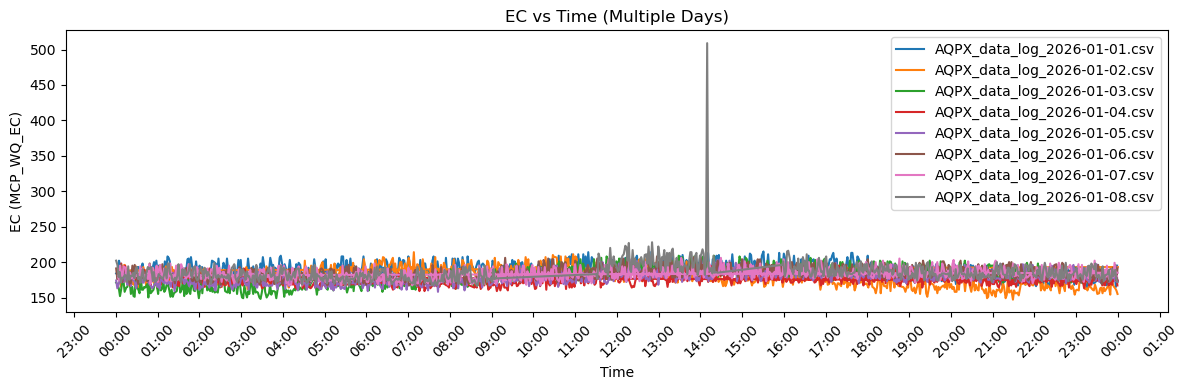

In [2]:
import glob

# ---- SETTINGS ----
folder = "C:\\Users\\Dindo\\Documents\\aqpx"
downsample_factor = 20

# ---- FIND ALL CSV FILES ----
csv_files = glob.glob(f"{folder}/*.csv")

print("Files found:", csv_files)

plt.figure(figsize=(12, 4))

# ---- PROCESS EACH FILE ----
for file in csv_files:
    print("Loading:", file)

    df = pd.read_csv(file)

    # Convert Time column
    df["Time"] = df["Time"].astype(str).str.strip()
    dtime = pd.to_datetime("2025-12-17 " + df["Time"], errors="coerce")

    # Get TDS values
    dec = df["MCP_WQ_EC"]

    # Downsample (optional)
    dtime_small = dtime[::downsample_factor]
    dec_small = dec[::downsample_factor]

    # Plot each CSV
    plt.plot(dtime_small, dec_small, label=file.split("\\")[-1])

# ---- GRAPH SETTINGS ----
plt.xlabel("Time")
plt.ylabel("EC (MCP_WQ_EC)")
plt.title("EC vs Time (Multiple Days)")

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Files found:
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-01.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-02.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-03.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-04.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-05.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-06.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-07.csv
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-08.csv
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-01.csv (date: 2026-01-01)
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-02.csv (date: 2026-01-02)
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-03.csv (date: 2026-01-03)
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-04.csv (date: 2026-01-04)
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-05.csv (date: 2026-01-05)
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-01-0

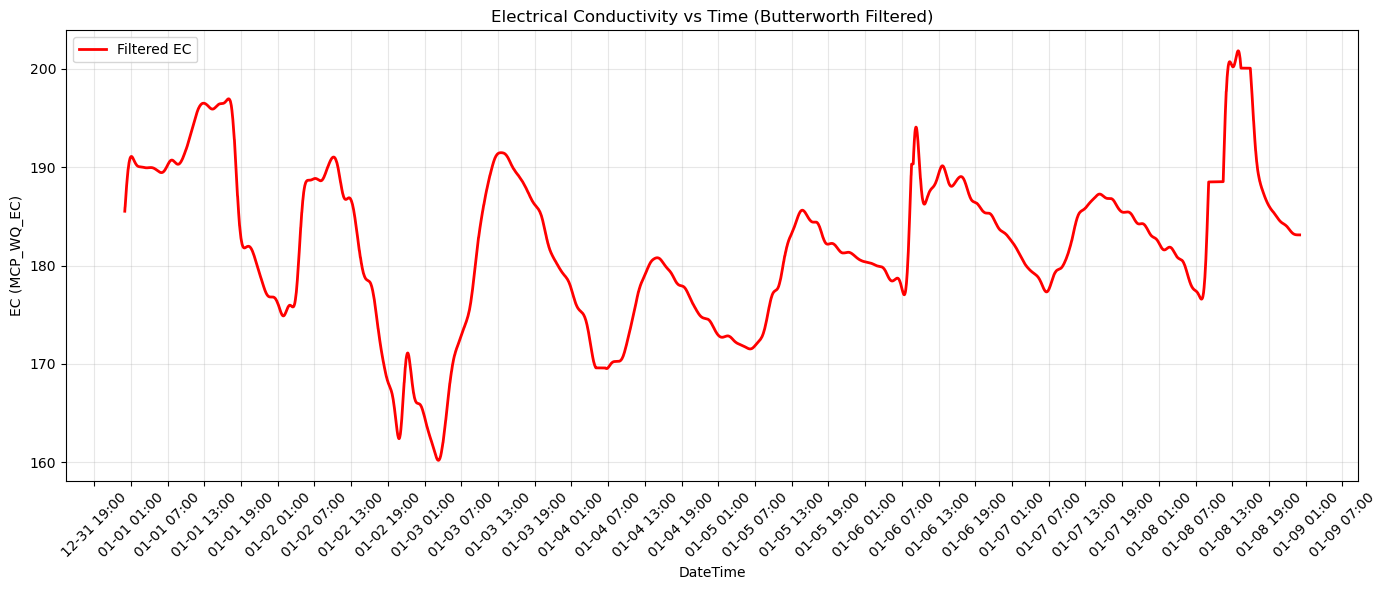


Filtering complete. Data range:
  Raw: 144.00 to 652.00
  Filtered: 160.20 to 201.82


In [21]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, sosfiltfilt

# -----------------------------
# 1. FOLDER WITH YOUR CSV FILES
# -----------------------------
folder = r"C:\Users\Dindo\Documents\aqpx"
csv_files = glob.glob(f"{folder}/*.csv")
print("Files found:")
for f in csv_files:
    print(" -", f)

frames = []

# -----------------------------
# 2. PROCESS EACH CSV
# -----------------------------
for file in csv_files:
    match = re.search(r"(\d{4}-\d{2}-\d{2})", file)
    if match:
        date_str = match.group(1)
    else:
        raise ValueError(f"ERROR: No date found in filename: {file}")
    
    print(f"Loading {file} (date: {date_str})")
    df = pd.read_csv(file)
    df["Time"] = df["Time"].astype(str).str.strip()
    df["DateTime"] = pd.to_datetime(
        date_str + " " + df["Time"],
        errors="coerce"
    )
    frames.append(df)

# -----------------------------
# 3. STITCH ALL CSVs TOGETHER
# -----------------------------
full_df = pd.concat(frames, ignore_index=True)
full_df = full_df.sort_values("DateTime").reset_index(drop=True)

print("\nStitched dataframe preview:")
print(full_df.head())
print(full_df.tail())

# --------------------------------
# 4. COMPUTE SAMPLING FREQUENCY (fs)
# --------------------------------
dt_seconds = full_df["DateTime"].diff().dt.total_seconds().median()
fs = 1.0 / dt_seconds
print(f"\nEstimated sampling frequency: {fs:.6f} Hz "
      f"(Δt ≈ {dt_seconds:.2f} s)")

# --------------------------------
# 5. DESIGN BUTTERWORTH SOS FILTER
# --------------------------------
# Choose cutoff based on what you want to preserve:
# - For hourly trends: cutoff = 1/(3600*2) ≈ 0.00014 Hz
# - For 30-min trends: cutoff = 1/(1800*2) ≈ 0.00028 Hz
# - For 15-min trends: cutoff = 1/(900*2) ≈ 0.00056 Hz

cutoff = 1.0 / (3600 * 2)  # Remove fluctuations faster than ~2 hours
order = 4

# Safety check
nyquist = fs / 2
if cutoff >= nyquist:
    print(f"WARNING: Cutoff {cutoff:.6f} Hz >= Nyquist {nyquist:.6f} Hz")
    cutoff = nyquist * 0.8  # Set to 80% of Nyquist
    print(f"Adjusting cutoff to {cutoff:.6f} Hz")

print(f"Filter cutoff: {cutoff:.6f} Hz (period: {1/cutoff/60:.1f} minutes)")

sos = butter(
    N=order,
    Wn=cutoff,
    btype="low",
    fs=fs,
    output="sos"
)

# --------------------------------
# 6. APPLY FILTER (with NaN handling)
# --------------------------------
ec = full_df["MCP_WQ_EC"].astype(float).values

# Check for NaNs
if np.any(np.isnan(ec)):
    print(f"WARNING: Found {np.sum(np.isnan(ec))} NaN values. Interpolating...")
    ec = pd.Series(ec).interpolate(method='linear').values

ec_filtered = sosfiltfilt(sos, ec)
full_df["EC_filtered"] = ec_filtered

# --------------------------------
# 7. PLOT RAW VS FILTERED (ALL DATA)
# --------------------------------
plt.figure(figsize=(14, 6))

plt.plot(full_df["DateTime"], full_df["EC_filtered"],
         label="Filtered EC", linewidth=2, color='red')

plt.title("Electrical Conductivity vs Time (Butterworth Filtered)")
plt.xlabel("DateTime")
plt.ylabel("EC (MCP_WQ_EC)")
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFiltering complete. Data range:")
print(f"  Raw: {full_df['MCP_WQ_EC'].min():.2f} to {full_df['MCP_WQ_EC'].max():.2f}")
print(f"  Filtered: {full_df['EC_filtered'].min():.2f} to {full_df['EC_filtered'].max():.2f}")